# High-dimensional Poisson problem: CP- and TT-PINNs with compressed Gauss–Newton

Companion notebook to the manuscript, Section *High-dimensional Poisson problem*. It reproduces the
CP/TT rank ablation. The default settings ($R=4$, $r=2$) give the first Poisson figure; setting
`CP_RANK = 9` and `TT_RANK = 3` gives the second.

## Problem

$$
-\Delta u_K^\star=f_K\quad\text{in }(0,1)^d,\qquad u_K^\star=0\quad\text{on }\partial(0,1)^d,\qquad d=25,
$$

with the paired target ($K=2^q$, $a(x)=\sin(\pi x)$, $b(x)=\sin(2\pi x)$)

$$
u_K^\star(z)=\frac{1}{\sqrt K}\prod_{\ell=1}^{q}\bigl[a(z_{2\ell-1})a(z_{2\ell})+b(z_{2\ell-1})b(z_{2\ell})\bigr]\prod_{m=2q+1}^{d}a(z_m).
$$

Its CP rank is exactly $K$, whereas its TT rank is two for every $K$. Increasing $K$ therefore
separates the two formats: a CP model of fixed rank $R$ can resolve the target only for $K\le R$,
while a TT model of rank two can resolve all of them. The source $f_K$ is available in closed form,
since each term of $u_K^\star$ is a Laplacian eigenfunction.

## Method

- **Ansatz.** `FORMAT` selects CP, $u_\theta=\sum_{\alpha=1}^{R}\prod_m u_m^\alpha(z_m)$, or TT,
  $u_\theta=G_1(z_1)\cdots G_d(z_d)$ with ranks $(1,r,\dots,r,1)$. Each factor or core is a $\tanh$
  network $1\to64\to64\to k_m$ ($k_m=R$ for CP, $k_m=r_{m-1}r_m$ for TT), multiplied by the boundary
  factor $\sqrt{15}\,z_m(1-z_m)$. TT cores use near-identity initialization.
- **Collocation.** One factor grid of $n=32$ uniformly drawn points per coordinate, fixed during
  training. The tensor grid ($32^{25}$ points) is never formed.
- **Compressed Gauss–Newton.** Each step is solved in the compressed space of dimension
  $N_{\rm eff}^{\rm CP}=2dnR$ or $N_{\rm eff}^{\rm TT}=2n\sum_s r_{s-1}r_s$, with damping $\mu=10^{-5}$ and
  a logarithmic line search. `SOLVER` switches between the dense and the compressed linear system;
  both give the same step, only the cost differs.
- **Ablation.** $K\in\{4,8,16,32\}$, 1000 iterations for CP and for TT. A common seed gives the same
  collocation grid to every run. The relative $L^2$ error is evaluated on midpoint grids with 256
  points per coordinate; compilation and error evaluation are excluded from the timings.

**Notebook layout.** Engine $\to$ hyperparameters $\to$ one training run with diagnostics and
solution plots $\to$ CP/TT ablation over $K$, figures and export (CSV table, JSON histories).

## CP/TT engine

Shared implementation of both formats: target and source, ansatz, factor-grid contractions, the
dense and compressed Gauss–Newton solvers and the training loop. Main correspondences with the
manuscript:

| manuscript | code |
|---|---|
| $k_s$ ($R$ for CP, $r_{s-1}r_s$ for TT) | `model.k_slots` |
| parameters $P_s$, $P$ | `model.P_slots`, `model.P` |
| compressed dimension $N_{\rm eff}$ | `model.N_eff` (asserted against `poisson_N_eff`) |
| residual block cores and insertions | `model.block_cores`, `model.insertions` |
| $\Upsilon$, $\rho_{\rm c}$, $\mathsf K_s$ | `Upsilon`, `rho_c`, `Ks` |

In [1]:
from dataclasses import dataclass, asdict, replace
from functools import partial
import time, json

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax import random, vmap, lax, jit
import numpy as np
import matplotlib.pyplot as plt

PI = jnp.pi
tree_map = jax.tree_util.tree_map

# Logarithmic line-search schedule
N_LINE_SEARCH = 31
MIN_LINE_SEARCH_STEP = 1e-6

LINE_SEARCH_STEPS = jnp.concatenate([
    jnp.logspace(
        0.0,
        jnp.log10(MIN_LINE_SEARCH_STEP),
        N_LINE_SEARCH,
    ),
    jnp.array([0.0]),
])

print("Line-search step-size schedule:")
print(np.asarray(LINE_SEARCH_STEPS))


@dataclass(frozen=True)
class Config:
    # Global choice: FORMAT determines which setup below is active.
    format: str = "cp"                  # "cp" or "tt"
    solver: str = "auto"                # "dense", "compressed", or "auto" ("woodbury" = legacy alias)

    # PDE and collocation.
    d: int = 25                          # dimension of D=(0,1)^d
    target_rank: int = 4                 # exact CP rank K=2^q; require 2q <= d
    n_per_axis: int = 128                # n_s: factor-grid points per coordinate
    iterations: int = 200
    error_every: int = 5                 # evaluate relative error every this many iterations
    mu: float = 1e-4                     # Levenberg damping
    seed: int = 0
    n_err: int = 256                     # univariate quadrature points for exact error
    resample_each_iteration: bool = False # False: one fixed factor grid per run

    # CP/separable PINN setup (k_s = R).
    cp_rank: int = 5
    cp_width: int = 14
    cp_hidden: int = 1

    # TT-PINN setup: ranks r_0 = r_d = 1, r_1 = ... = r_{d-1} = tt_rank.
    tt_rank: int = 2
    tt_width: int = 32
    tt_hidden: int = 1
    tt_init_mode: str = "near_identity"  # "near_identity" or "random"
    tt_identity_epsilon: float = 0.30     # perturbation size in G_m = I_r + eps H_m
    tt_global_scale: bool = True          # one global amplitude instead of per-core RMS scales

    # Compressed route (Algorithm 1): pivoted LU of Upsilon K + mu I.
    compressed_refine: int = 1           # iterative-refinement sweeps on the unperturbed system

    @property
    def active_rank(self):
        return self.cp_rank if self.format.lower() == "cp" else self.tt_rank

    @property
    def active_width(self):
        return self.cp_width if self.format.lower() == "cp" else self.tt_width

    @property
    def active_hidden(self):
        return self.cp_hidden if self.format.lower() == "cp" else self.tt_hidden


def tt_ranks(d, r):
    """TT ranks (r_0, ..., r_d) with r_0 = r_d = 1, eq. (tt_ansatz)."""
    return (1,) + (int(r),) * (d - 1) + (1,)


def poisson_N_eff(fmt, d, n, rank):
    """Effective compressed dimension, eq. (poisson_local_channel_dimensions):

        CP: N_eff^{ch,CP} = 2 R sum_s n_s,
        TT: N_eff^{ch,TT} = 2 sum_s n_s r_{s-1} r_s   (r_0 = r_d = 1).

    Written independently of the solver bookkeeping, as a check.
    """
    if fmt.lower() == "cp":
        return int(2 * rank * d * n)
    ranks = tt_ranks(d, rank)
    return int(sum(2 * n * ranks[s - 1] * ranks[s] for s in range(1, d + 1)))


# ======================================================================
# Slot runs.  Consecutive slots with identical local shapes form a run and
# are processed by one vmap / one fori_loop.  CP: one run with k_s = R.
# TT: {1} (1 x r), {2..d-1} (r x r), {d} (r x 1).
# ======================================================================
@dataclass(frozen=True)
class SlotRun:
    start: int                 # first slot (0-based, inclusive)
    stop: int                  # last slot + 1
    k: int                     # k_s (CP: R, TT: r_{s-1} r_s)
    units: tuple               # active local indices a_s, flat in the padded c x c core
    n: int                     # n_s
    P_slot: int                # P_s
    N_offset: int              # offset of the first slot in the compressed index
    P_offset: int              # offset of the first slot in the parameter index
    L: int = 2                 # |Lambda_s| = |{0, 2}|

    @property
    def length(self):
        return self.stop - self.start

    @property
    def N_slot(self):          # N_s^ch = 2 n_s k_s
        return self.L * self.n * self.k


def build_slot_runs(fmt, d, c, n, widths):
    hidden = 0
    sizes = (1,) + tuple(widths)
    for a, b in zip(sizes[:-1], sizes[1:]):
        hidden += a * b + b
    w_in = widths[-1] if widths else 1
    if fmt == "cp":
        signatures = [("cp", c)] * d
        unit_of = {("cp", c): tuple(a * c + a for a in range(c))}          # diagonal units e_a e_a^T
    else:
        ranks = tt_ranks(d, c)
        signatures = [("tt", ranks[s], ranks[s + 1]) for s in range(d)]
        unit_of = {sig: tuple(a * c + b for a in range(sig[1]) for b in range(sig[2]))
                   for sig in set(signatures)}
    runs, s, N_off, P_off = [], 0, 0, 0
    while s < d:
        e = s
        while e < d and signatures[e] == signatures[s]:
            e += 1
        units = unit_of[signatures[s]]
        k = len(units)
        run = SlotRun(start=s, stop=e, k=k, units=units, n=n,
                      P_slot=hidden + w_in * k + k, N_offset=N_off, P_offset=P_off)
        runs.append(run)
        N_off += run.length * run.N_slot
        P_off += run.length * run.P_slot
        s = e
    return tuple(runs)


class Model:
    """CP/TT separable PINN engine with dense and compressed Gauss--Newton solvers.

    Notation (manuscript -> code):
      local channels Lambda_s = {0, 2}: (G_s, G_s'')                   -> core_channels (d, n, 2, c, c)
      CP: u = sum_alpha prod_m u_m^alpha, cores diag(u_m^alpha)        -> units on the diagonal
      TT: u = G_1 ... G_d, ranks (1, r, ..., r, 1)
      block cores B_m^Delta = [[G_m, -G_m''], [0, G_m]]                  -> block_cores   (d, n, q, q), q = 2c
      insertions P_{s,0,a} = diag(M_a, M_a), P_{s,2,a} = [[0,-M_a],[0,0]] -> insertions    (2, k_s, q, q)
      C_s^ch = col(H_{s,0}, H_{s,2}), rows ordered (l, i_s, a_s)          -> Cs (per run)
      Upsilon = (1/N_D) Psi^T Psi, rho_c = (1/N_D) Psi^T rho(theta)      -> Upsilon, rho_c
      K = C C^T = diag(K_s)                                              -> Ks
      compressed step (Upsilon K + mu I) y = rho_c, delta = C^T y        -> solve_compressed
      dense step (C^T Upsilon C + mu I) delta = C^T rho_c                -> solve_dense
    The source f_K is kept as its own rank-K CP chain; rho = -Delta u_theta - f_K.
    """

    def __init__(self, cfg: Config):
        fmt = cfg.format.lower()
        if fmt not in {"cp", "tt"}:
            raise ValueError("cfg.format must be 'cp' or 'tt'.")
        if cfg.solver.lower() not in {"dense", "compressed", "woodbury", "auto"}:
            raise ValueError("cfg.solver must be 'dense', 'compressed', or 'auto'.")
        if cfg.mu <= 0.0:
            raise ValueError("mu must be strictly positive.")
        if cfg.tt_init_mode.lower() not in {"near_identity", "random"}:
            raise ValueError("cfg.tt_init_mode must be 'near_identity' or 'random'.")
        if cfg.tt_identity_epsilon < 0.0:
            raise ValueError("cfg.tt_identity_epsilon must be nonnegative.")
        K = int(cfg.target_rank)
        if K < 1 or (K & (K - 1)) != 0:
            raise ValueError("target_rank must be a positive power of two, K=2^q.")
        q = K.bit_length() - 1
        if 2 * q > cfg.d:
            raise ValueError("target_rank=2^q requires 2q <= d because each pair uses two coordinates.")

        self.cfg = cfg
        self.format = fmt
        d, c = cfg.d, cfg.active_rank
        self.target_rank = K
        self.target_pairs = q
        self.c = c                                   # CP rank R or TT rank r
        self.RF = K                                  # CP rank of the target / source
        self.q = 2 * c                               # block-core size
        self.widths = (cfg.active_width,) * cfg.active_hidden
        self.runs = build_slot_runs(fmt, d, c, cfg.n_per_axis, self.widths)
        self.ranks = tt_ranks(d, c) if fmt == "tt" else None
        self.P = sum(run.length * run.P_slot for run in self.runs)
        self.P_slots = tuple(run.P_slot for run in self.runs for _ in range(run.length))
        self.P_axis = max(self.P_slots)              # interior core / factor network
        self.sizes = (1,) + self.widths + (max(run.k for run in self.runs),)
        self.k_slots = tuple(run.k for run in self.runs for _ in range(run.length))
        self.N_slots = tuple(run.N_slot for run in self.runs for _ in range(run.length))
        self.N_eff = sum(self.N_slots)
        assert self.N_eff == poisson_N_eff(fmt, d, cfg.n_per_axis, c)
        self.L_channels = 2
        self._layouts = {}

        # ---- manufactured solution -------------------------------------
        # K=2^q mutually orthogonal CP terms are generated by q adjacent pairs:
        #   [sin(pi z_{2l-1})sin(pi z_{2l}) + sin(2pi z_{2l-1})sin(2pi z_{2l})].
        bit_ids = jnp.arange(K, dtype=jnp.int32)[:, None]
        bit_pos = jnp.arange(q, dtype=jnp.int32)[None, :]
        self.target_bits = (bit_ids >> bit_pos) & 1          # (K,q)
        self.pair_frequencies = 1 + jnp.repeat(self.target_bits.T, 2, axis=0)   # (2q,K)
        self.C_target = jnp.ones((K,)) / jnp.sqrt(float(K))
        eigs = PI**2 * (d + 6 * jnp.sum(self.target_bits, axis=1))
        self.C_source = eigs * self.C_target

        # ---- boundary vectors ------------------------------------------
        if fmt == "cp":
            self.lvec = jnp.ones((c,))
            self.rvec = jnp.ones((c,))
        else:
            self.lvec = jnp.zeros((c,)).at[0].set(1.0)
            self.rvec = jnp.zeros((c,)).at[0].set(1.0)
        self.op_left = jnp.concatenate([self.lvec, jnp.zeros((c,))])
        self.op_right = jnp.concatenate([jnp.zeros((c,)), self.rvec])
        self.ones_K = jnp.ones((K,))
        self.ell_scale = float(np.sqrt(15.0))
        self.matrix_units = jnp.eye(c * c).reshape(c * c, c, c)

    # ---------------- factor/core networks ----------------
    def _layout(self, k):
        if k not in self._layouts:
            sizes = (1,) + self.widths + (k,)
            layers = tuple(zip(sizes[:-1], sizes[1:]))
            off = [0]
            for m_in, n_out in layers:
                off.append(off[-1] + n_out * m_in + n_out)
            self._layouts[k] = (sizes, layers, tuple(off))
        return self._layouts[k]

    def network_sizes(self, run):
        return self._layout(run.k)[0]

    def mlp(self, theta_slot, x, k):
        _, layers, offsets = self._layout(k)
        z = jnp.atleast_1d(x)
        for ell, (m_in, n_out) in enumerate(layers):
            o = offsets[ell]
            w = lax.dynamic_slice(theta_slot, (o,), (n_out * m_in,)).reshape((n_out, m_in))
            b = lax.dynamic_slice(theta_slot, (o + n_out * m_in,), (n_out,))
            z = w @ z + b
            if ell < len(layers) - 1:
                z = jnp.tanh(z)
        return z

    def _value(self, theta_slot, s, scale, k):
        return scale * self.ell_scale * s * (1.0 - s) * self.mlp(theta_slot, s, k)

    def _channels(self, theta_slot, s, scale, k):
        """(D_{s,l} G_s)(z) for l in Lambda_s = {0, 2}: shape (2, k)."""
        f = lambda t: self._value(theta_slot, t, scale, k)
        d1 = lambda t: jax.jvp(f, (t,), (1.0,))[1]
        value = f(s)
        _, second = jax.jvp(d1, (s,), (1.0,))
        return jnp.stack([value, second])

    def _channels_and_H(self, theta_slot, s, scale, k):
        vals, pull = jax.vjp(lambda th: self._channels(th, s, scale, k).reshape(-1), theta_slot)
        H = vmap(lambda e: pull(e)[0])(jnp.eye(2 * k, dtype=theta_slot.dtype))
        return vals.reshape(2, k), H.reshape(2, k, -1)

    def _pad(self, local, run, channels):
        """(..., channels, k) -> (..., channels, c, c) on the active units."""
        c = self.c
        flat = jnp.zeros(local.shape[:-1] + (c * c,), dtype=local.dtype)
        flat = flat.at[..., jnp.asarray(run.units)].set(local)
        return flat.reshape(local.shape[:-1] + (c, c))

    def core_values(self, theta, grids, scales):
        """Padded value cores G_s(z) on arbitrary per-slot grids: (d, n, c, c)."""
        out = []
        for run, th in zip(self.runs, theta):
            sl = slice(run.start, run.stop)
            f = lambda t, zs, sc: vmap(lambda z: self._value(t, z, sc, run.k))(zs)
            out.append(self._pad(vmap(f)(th, grids[sl], scales[sl]), run, 1))
        return jnp.concatenate(out, axis=0)

    def core_channels(self, theta, grids, scales):
        """Padded (G_s, G_s'') on the factor grids: (d, n, 2, c, c)."""
        out = []
        for run, th in zip(self.runs, theta):
            sl = slice(run.start, run.stop)
            f = lambda t, zs, sc: vmap(lambda z: self._channels(t, z, sc, run.k))(zs)
            out.append(self._pad(vmap(f)(th, grids[sl], scales[sl]), run, 2))
        return jnp.concatenate(out, axis=0)

    def core_channels_and_C(self, theta, grids, scales):
        """Padded channels and C_s^ch = col(H_{s,0}, H_{s,2}), rows (l, i_s, a_s)."""
        cores, Cs = [], []
        for run, th in zip(self.runs, theta):
            sl = slice(run.start, run.stop)
            f = lambda t, zs, sc: vmap(lambda z: self._channels_and_H(t, z, sc, run.k))(zs)
            vals, H = vmap(f)(th, grids[sl], scales[sl])          # (len,n,2,k), (len,n,2,k,P)
            cores.append(self._pad(vals, run, 2))
            H = jnp.transpose(H, (0, 2, 1, 3, 4))                 # (len, 2, n, k, P)
            Cs.append(H.reshape(run.length, run.N_slot, run.P_slot))
        return jnp.concatenate(cores, axis=0), tuple(Cs)

    def init_theta(self, key):
        """Initialize the univariate factor/core networks.

        CP keeps the fan-in random initialization.  In the TT branch,
        ``near_identity`` keeps all hidden layers fully active but initializes
        the final matrix-valued output before the fixed boundary factor as
        G_m(z_m) = I_r + eps * H_m(z_m); only the final-layer weights are
        reduced and its bias is vec(I_r).  Every TT core is drawn as an r x r
        network (same random stream as before) and only the parameters of the
        active outputs are kept, so for a given seed the GN trajectory
        coincides with the previous all-r x r notebook.
        """
        near_identity = (self.format == "tt" and self.cfg.tt_init_mode.lower() == "near_identity")
        Q = self.c if self.format == "cp" else self.c * self.c
        _, full_layers, full_offsets = self._layout(Q)

        def one(k):
            parts = []
            layer_keys = random.split(k, len(full_layers))
            for ell, (kk, (m_in, n_out)) in enumerate(zip(layer_keys, full_layers)):
                kw, kb = random.split(kk)
                is_output = ell == len(full_layers) - 1
                if near_identity and is_output:
                    v = self.cfg.tt_identity_epsilon * jnp.sqrt(1.0 / m_in)
                    w = random.uniform(kw, (n_out, m_in), minval=-v, maxval=v)
                    b = jnp.eye(self.c, dtype=w.dtype).reshape(-1)
                else:
                    v = jnp.sqrt(1.0 / m_in)
                    w = random.uniform(kw, (n_out, m_in), minval=-v, maxval=v)
                    b = random.uniform(kb, (n_out,), minval=-v, maxval=v)
                parts.append(w.ravel())
                parts.append(b)
            return jnp.concatenate(parts)

        full = vmap(one)(random.split(key, self.cfg.d))
        n_in = full_layers[-1][0]
        o = full_offsets[-2]
        theta = []
        for run in self.runs:
            if self.format == "cp":
                active = np.arange(Q)
            else:
                active = np.asarray(run.units)          # flat index in r x r = output index
            idx = np.concatenate([
                np.arange(o),
                (o + active[:, None] * n_in + np.arange(n_in)[None, :]).ravel(),
                o + Q * n_in + active,
            ])
            theta.append(full[run.start:run.stop][:, idx])
        return tuple(theta)

    # ---------------- target and source ----------------
    def target_factors(self, grids):
        """Slotwise factors of the paired exact solution and its source: (d, n, K)."""
        base = jnp.sin(PI * grids)
        T = jnp.tile(base[:, :, None], (1, 1, self.RF))
        if self.target_pairs:
            paired = jnp.sin(
                PI * grids[:2 * self.target_pairs, :, None] * self.pair_frequencies[:, None, :]
            )
            T = T.at[:2 * self.target_pairs].set(paired)
        return T

    def target_values(self, grids, coeffs):
        return self.target_factors(grids).at[0].multiply(coeffs[None, :])

    # ---------------- block chain and environments ----------------
    def block_cores(self, cores):
        """B_m^Delta = [[G_m, -G_m''], [0, G_m]]: (d, n, 2c, 2c)."""
        G, G2 = cores[:, :, 0], cores[:, :, 1]
        Z = jnp.zeros_like(G)
        return jnp.concatenate([
            jnp.concatenate([G, -G2], axis=-1),
            jnp.concatenate([Z, G], axis=-1),
        ], axis=-2)

    def insertions(self, run):
        """P_{s,0,a} = diag(M_a, M_a), P_{s,2,a} = [[0, -M_a], [0, 0]]: (2, k, q, q)."""
        M = self.matrix_units[jnp.asarray(run.units)]
        Z = jnp.zeros_like(M)
        P0 = jnp.concatenate([jnp.concatenate([M, Z], -1), jnp.concatenate([Z, M], -1)], -2)
        P2 = jnp.concatenate([jnp.concatenate([Z, -M], -1), jnp.concatenate([Z, Z], -1)], -2)
        return jnp.stack([P0, P2])

    @staticmethod
    def _transfer(GA, GB):
        """T[a,b,c,e] = (1/n) sum_i GA[i,a,c] GB[i,b,e] (one slot)."""
        return jnp.einsum("iac,ibe->abce", GA, GB) / GA.shape[0]

    @staticmethod
    def _env_mm(T, left, right):
        L0, R0 = jnp.outer(left, left), jnp.outer(right, right)
        Lfin, Lb = lax.scan(lambda L, Tm: (jnp.einsum("ab,abce->ce", L, Tm), L), L0, T)
        _, Ra = lax.scan(lambda R, Tm: (jnp.einsum("abce,ce->ab", Tm, R), R), R0, T, reverse=True)
        return Lb, Ra, jnp.einsum("ac,a,c->", Lfin, right, right)

    @staticmethod
    def _env_mf(Gm, S, left_m, right_m, ones):
        """Environments of (block chain) x (diagonal CP source chain S: (d, n, K))."""
        n = Gm.shape[1]
        L0, R0 = jnp.outer(left_m, ones), jnp.outer(right_m, ones)
        lstep = lambda L, x: (jnp.einsum("ac,iab,ic->bc", L, x[0], x[1]) / n, L)
        rstep = lambda R, x: (jnp.einsum("iab,ic,bc->ac", x[0], x[1], R) / n, R)
        Lfin, Lb = lax.scan(lstep, L0, (Gm, S))
        _, Ra = lax.scan(rstep, R0, (Gm, S), reverse=True)
        return Lb, Ra, jnp.einsum("ac,a,c->", Lfin, right_m, ones)

    @staticmethod
    def _quad_ff(S):
        """<f, f> for a diagonal CP chain (coefficients already folded into S[0])."""
        n = S.shape[1]
        Gm = jnp.einsum("dia,dib->dab", S, S) / n
        return jnp.sum(jnp.prod(Gm, axis=0))

    def _loss_from_cores(self, cores, grids):
        Gm = self.block_cores(cores)
        S = self.target_values(grids, self.C_source)
        n = grids.shape[1]

        def lstep(L, G):
            return jnp.einsum("ac,iab,icd->bd", L, G, G) / n, None

        Lmm, _ = lax.scan(lstep, jnp.outer(self.op_left, self.op_left), Gm)
        qmm = jnp.einsum("ac,a,c->", Lmm, self.op_right, self.op_right)
        _, _, qmf = self._env_mf(Gm, S, self.op_left, self.op_right, self.ones_K)
        return 0.5 * (qmm - 2.0 * qmf + self._quad_ff(S))

    def loss(self, theta, grids, scales):
        return self._loss_from_cores(self.core_channels(theta, grids, scales), grids)

    # ---------------- assembly of the GN system ----------------
    def _assemble(self, theta, grids, scales, parameter_space):
        """Assemble (Upsilon, rho_c) or, with parameter_space=True,
        (C^T Upsilon C, C^T rho_c) without forming Upsilon.

        Upper blocks are computed by a sweep: the state after the insertion at
        slot s is contracted with the right functional F_t of slot t and then
        pushed through slot t with the transfer operator T_t.  Only the model
        block chain (size 2c) enters Upsilon; the source chain enters rho_c.
        """
        n, q = grids.shape[1], self.q
        cores, Cs = self.core_channels_and_C(theta, grids, scales)
        Gm = self.block_cores(cores)
        S = self.target_values(grids, self.C_source)

        Tmm = vmap(self._transfer)(Gm, Gm)
        Lmm, Rmm, qmm = self._env_mm(Tmm, self.op_left, self.op_right)
        Lmf, Rmf, qmf = self._env_mf(Gm, S, self.op_left, self.op_right, self.ones_K)
        loss = 0.5 * (qmm - 2.0 * qmf + self._quad_ff(S))

        def row_size(run):
            return run.P_slot if parameter_space else run.N_slot

        def row_offset(run, s):
            return (run.P_offset if parameter_space else run.N_offset) + (s - run.start) * row_size(run)

        size = self.P if parameter_space else self.N_eff
        dtype = Gm.dtype
        M = jnp.zeros((size, size), dtype=dtype)
        vec = jnp.zeros((size,), dtype=dtype)
        eye_n = jnp.eye(n, dtype=dtype)

        def C_of(ri, s):
            return lax.dynamic_index_in_dim(Cs[ri], s - self.runs[ri].start, keepdims=False)

        for ri, rs in enumerate(self.runs):
            Ps = self.insertions(rs)                              # (2, k, q, q), independent of z
            def s_body(s, carry, ri=ri, rs=rs, Ps=Ps):
                M, vec = carry
                take = lambda A: lax.dynamic_index_in_dim(A, s, keepdims=False)
                G_s, S_s = take(Gm), take(S)
                Lmm_s, Rmm_s, Lmf_s, Rmf_s = take(Lmm), take(Rmm), take(Lmf), take(Rmf)
                Ns = rs.N_slot

                # rho_c block, ordered (l, i_s, a_s).
                rho_m = jnp.einsum("ac,luab,pcd,bd->lpu", Lmm_s, Ps, G_s, Rmm_s)
                rho_f = jnp.einsum("ac,luab,pc,bc->lpu", Lmf_s, Ps, S_s, Rmf_s)
                rho_s = ((rho_m - rho_f) / n).reshape(Ns)

                # Diagonal block: the insertions do not depend on z, so
                # Upsilon_ss = (D0 on (l, a)) (x) I_n in the (l, i_s, a_s) ordering.
                D0 = jnp.einsum("ac,luab,mvcd,bd->lumv", Lmm_s, Ps, Ps, Rmm_s) / n
                D = jnp.einsum("lumv,pw->lpumwv", D0, eye_n).reshape(Ns, Ns)

                # State after the insertion at slot s.
                X = (jnp.einsum("ac,luab,pcd->lpubd", Lmm_s, Ps, G_s) / n).reshape(Ns, q, q)

                if parameter_space:
                    C_s = C_of(ri, s)
                    rho_s = C_s.T @ rho_s
                    D = C_s.T @ D @ C_s
                    X = jnp.einsum("uab,up->pab", X, C_s)

                off_s = row_offset(rs, s)
                vec = lax.dynamic_update_slice(vec, rho_s, (off_s,))
                M = lax.dynamic_update_slice(M, D, (off_s, off_s))

                for rj in range(ri, len(self.runs)):
                    rt = self.runs[rj]
                    Pt = self.insertions(rt)

                    def t_body(t, inner, rj=rj, rt=rt, Pt=Pt):
                        X, M = inner
                        take_t = lambda A: lax.dynamic_index_in_dim(A, t, keepdims=False)
                        F = jnp.einsum("pab,lucd,bd->lpuac", take_t(Gm), Pt, take_t(Rmm)) / n
                        F = F.reshape(rt.N_slot, q, q)
                        blk = jnp.einsum("uab,vab->uv", X, F)
                        if parameter_space:
                            blk = blk @ C_of(rj, t)
                        off_t = row_offset(rt, t)
                        M = lax.dynamic_update_slice(M, blk, (off_s, off_t))
                        M = lax.dynamic_update_slice(M, blk.T, (off_t, off_s))
                        X = jnp.einsum("uab,abce->uce", X, take_t(Tmm))
                        return X, M

                    lo = jnp.maximum(rt.start, s + 1)
                    X, M = lax.fori_loop(lo, rt.stop, t_body, (X, M))
                return M, vec

            M, vec = lax.fori_loop(rs.start, rs.stop, s_body, (M, vec))
        return loss, Cs, vec, M

    def compressed_system(self, theta, grids, scales):
        """loss, C blocks, rho_c (N_eff,), Upsilon (N_eff x N_eff)."""
        return self._assemble(theta, grids, scales, parameter_space=False)

    def gauss_newton_system(self, theta, grids, scales):
        """loss, gradient C^T rho_c (P,), Gauss--Newton matrix C^T Upsilon C (P x P)."""
        loss, _, grad, gram = self._assemble(theta, grids, scales, parameter_space=True)
        return loss, grad, gram

    # ---------------- linear solves ----------------
    def _split_params(self, vector):
        out = []
        for run in self.runs:
            seg = lax.dynamic_slice(vector, (run.P_offset,), (run.length * run.P_slot,))
            out.append(seg.reshape(run.length, run.P_slot))
        return tuple(out)

    def solve_dense(self, grad, gram):
        """(C^T Upsilon C + mu I_P) delta = C^T rho_c by Cholesky."""
        chol = jnp.linalg.cholesky(gram + self.cfg.mu * jnp.eye(self.P, dtype=gram.dtype))
        return self._split_params(jax.scipy.linalg.cho_solve((chol, True), grad))

    def _apply_K(self, Ks, y):
        parts = []
        for run, K in zip(self.runs, Ks):
            ys = lax.dynamic_slice(y, (run.N_offset,), (run.length * run.N_slot,))
            parts.append(jnp.einsum("luv,lv->lu", K, ys.reshape(run.length, run.N_slot)).reshape(-1))
        return jnp.concatenate(parts)

    def solve_compressed(self, Cs, rho_c, Upsilon):
        """(Upsilon K + mu I) y = rho_c by pivoted LU, delta = C^T y (Algorithm 1).

        A_{:,t} = Upsilon_{:,t} K_t is formed block-column-wise, so the
        block-diagonal K is never stored as an N_eff x N_eff matrix.
        """
        N = self.N_eff
        Ks = tuple(jnp.einsum("lup,lvp->luv", C, C) for C in Cs)
        cols = []
        for run, K in zip(self.runs, Ks):
            U = lax.dynamic_slice_in_dim(Upsilon, run.N_offset, run.length * run.N_slot, axis=1)
            cols.append(jnp.einsum("Nlu,luv->Nlv", U.reshape(N, run.length, run.N_slot), K).reshape(N, -1))
        A = jnp.concatenate(cols, axis=1) + self.cfg.mu * jnp.eye(N, dtype=Upsilon.dtype)
        lu = jax.scipy.linalg.lu_factor(A)
        apply_inv = lambda v: jax.scipy.linalg.lu_solve(lu, v)
        y = apply_inv(rho_c)
        for _ in range(self.cfg.compressed_refine):
            y = y + apply_inv(rho_c - (Upsilon @ self._apply_K(Ks, y) + self.cfg.mu * y))
        delta = []
        for run, C in zip(self.runs, Cs):
            ys = lax.dynamic_slice(y, (run.N_offset,), (run.length * run.N_slot,))
            delta.append(jnp.einsum("lup,lu->lp", C, ys.reshape(run.length, run.N_slot)))
        return tuple(delta)

    def solver_used(self):
        requested = self.cfg.solver.lower()
        if requested == "woodbury":
            requested = "compressed"
        if requested == "auto":
            return "compressed" if self.N_eff < self.P else "dense"
        return requested

    @property
    def N_axis(self):
        """N_s^ch of an interior slot."""
        return max(self.N_slots)

    def gauss_newton_step(self, theta, grids, scales):
        if self.solver_used() == "compressed":
            loss, Cs, rho_c, Upsilon = self.compressed_system(theta, grids, scales)
            delta = self.solve_compressed(Cs, rho_c, Upsilon)
        else:
            loss, grad, gram = self.gauss_newton_system(theta, grids, scales)
            delta = self.solve_dense(grad, gram)
        finite = jnp.all(jnp.stack([jnp.all(jnp.isfinite(x)) for x in delta]))
        return loss, tree_map(lambda x: jnp.where(finite, x, 0.0), delta)

    # ---------------- exact error and evaluation ----------------
    def _pair_value(self, A, la, ra, B, lb, rb):
        n = A.shape[1]
        st, _ = lax.scan(lambda s, x: (jnp.einsum("ac,iab,icd->bd", s, x[0], x[1]) / n, None),
                         jnp.outer(la, lb), (A, B))
        return jnp.einsum("ac,a,c->", st, ra, rb)

    def relative_error(self, theta, scales):
        n = self.cfg.n_err
        pts = (jnp.arange(n) + 0.5) / n
        grids = jnp.tile(pts[None, :], (self.cfg.d, 1))
        U = self.core_values(theta, grids, scales)
        T = self.target_values(grids, self.C_target)                 # diagonal CP chain
        mm = self._pair_value(U, self.lvec, self.rvec, U, self.lvec, self.rvec)
        st, _ = lax.scan(lambda s, x: (jnp.einsum("ac,iab,ic->bc", s, x[0], x[1]) / n, None),
                         jnp.outer(self.lvec, self.ones_K), (U, T))
        mt = jnp.einsum("ac,a,c->", st, self.rvec, self.ones_K)
        tt = self._quad_ff(T)
        return jnp.sqrt(jnp.maximum(mm - 2.0 * mt + tt, 0.0) / tt)

    def _chain_points(self, U):
        st, _ = lax.scan(lambda s, A: (jnp.einsum("na,nab->nb", s, A), None),
                         jnp.tile(self.lvec[None, :], (U.shape[1], 1)), U)
        return st @ self.rvec

    def model_points(self, theta, X, scales):
        return self._chain_points(self.core_values(theta, X.T, scales))

    def exact_points(self, X):
        return jnp.prod(self.target_factors(X.T), axis=0) @ self.C_target

    def model_slice(self, theta, xs, ys, fixed, scales, axes=(0, 1)):
        s, t = axes
        fixed = jnp.asarray(fixed)
        n1, n2 = xs.shape[0], ys.shape[0]
        g_fix = self.core_values(theta, fixed[:, None], scales)[:, 0]        # (d, c, c)
        g_s = self.core_values(theta, jnp.tile(xs[None, :], (self.cfg.d, 1)), scales)[s]
        g_t = self.core_values(theta, jnp.tile(ys[None, :], (self.cfg.d, 1)), scales)[t]
        lo, hi = min(s, t), max(s, t)
        left = self.lvec
        for m in range(lo):
            left = left @ g_fix[m]
        right = self.rvec
        for m in range(self.cfg.d - 1, hi, -1):
            right = g_fix[m] @ right
        mid = jnp.eye(self.c)
        for m in range(lo + 1, hi):
            mid = mid @ g_fix[m]
        g_lo, g_hi = (g_s, g_t) if s < t else (g_t, g_s)
        a = jnp.einsum("a,iab->ib", left, g_lo) @ mid                        # (n_lo, c)
        b = jnp.einsum("jbc,c->jb", g_hi, right)                             # (n_hi, c)
        out = a @ b.T
        return out if s < t else out.T

    def exact_slice(self, xs, ys, fixed, axes=(0, 1)):
        s, t = axes
        others = jnp.array([m for m in range(self.cfg.d) if m not in axes])
        T_full = self.target_factors(jnp.asarray(fixed)[:, None])
        w = jnp.prod(T_full[others, 0, :], axis=0) * self.C_target
        T_s = self.target_factors(jnp.tile(xs[None, :], (self.cfg.d, 1)))[s]
        T_t = self.target_factors(jnp.tile(ys[None, :], (self.cfg.d, 1)))[t]
        return (T_s * w[None, :]) @ T_t.T

    # ---------------- initialization and diagnostics ----------------
    def factor_scales(self, theta, n_probe=512):
        probe = (jnp.arange(n_probe) + 0.5) / n_probe
        grids = jnp.tile(probe[None, :], (self.cfg.d, 1))
        unit_scales = jnp.ones((self.cfg.d,))
        U = self.core_values(theta, grids, unit_scales)

        # The K^{-1/2} target normalization makes ||u_K^*|| independent of K.
        target = jnp.prod(jnp.sqrt(jnp.mean(jnp.sin(PI * grids) ** 2, axis=1)))

        if (self.format == "tt" and self.cfg.tt_init_mode.lower() == "near_identity"
                and self.cfg.tt_global_scale):
            # One global amplitude from a factorized L2 contraction.
            raw_norm_sq = self._pair_value(U, self.lvec, self.rvec, U, self.lvec, self.rvec)
            alpha = target / jnp.sqrt(jnp.maximum(raw_norm_sq, 1e-24))
            return unit_scales.at[0].set(alpha)

        # Per-core RMS normalization over the active outputs.
        rms = jnp.sqrt(jnp.sum(U**2, axis=(1, 2, 3)) / (n_probe * jnp.asarray(self.k_slots)))
        paths = float(self.c) if self.format == "cp" else float(self.c) ** (self.cfg.d - 1)
        sigma = (target / jnp.sqrt(paths)) ** (1.0 / self.cfg.d)
        return sigma / jnp.maximum(rms, 1e-12)

    def initialization_diagnostics(self, theta, scales, n_probe=256):
        """Report how close the TT MLP cores are to I_r before boundary factors."""
        if self.format != "tt":
            return dict(init_mode="random", global_scale=None,
                        mean_core_identity_deviation=None, max_core_identity_deviation=None)
        probe = (jnp.arange(n_probe) + 0.5) / n_probe
        grids = jnp.tile(probe[None, :], (self.cfg.d, 1))
        identity = jnp.eye(self.c).reshape(-1)
        devs = []
        for run, th in zip(self.runs, theta):
            raw = vmap(lambda t, zs: vmap(lambda z: self.mlp(t, z, run.k))(zs))(
                th, grids[run.start:run.stop])
            devs.append(jnp.sqrt(jnp.mean((raw - identity[jnp.asarray(run.units)]) ** 2, axis=(1, 2))))
        dev = jnp.concatenate(devs)
        use_global = self.cfg.tt_init_mode.lower() == "near_identity" and self.cfg.tt_global_scale
        return dict(
            init_mode=self.cfg.tt_init_mode.lower(),
            global_scale=(float(np.asarray(scales[0])) if use_global else None),
            mean_core_identity_deviation=float(np.asarray(jnp.mean(dev))),
            max_core_identity_deviation=float(np.asarray(jnp.max(dev))),
        )

    def dof(self):
        d, R = self.cfg.d, self.c
        gauge = (d - 1) * R if self.format == "cp" else (d - 1) * R * R
        return dict(P=self.P, P_axis=self.P_axis, gauge=int(gauge), P_eff_analytic=int(self.P - gauge))

    def effective_dof(self, gram, mu=None):
        mu = self.cfg.mu if mu is None else mu
        ev = jnp.clip(jnp.linalg.eigvalsh(gram), 0.0, None)
        return float(jnp.sum(ev / (ev + mu)))

    def spectrum(self, gram):
        return np.asarray(jnp.clip(jnp.linalg.eigvalsh(gram), 0.0, None))[::-1]


# ============================================================
# Training in compiled chunks, with sparse error evaluation
# ============================================================
def make_trainer(model: Model):
    cfg = model.cfg
    d = cfg.d

    def iteration(carry, _):
        theta, key, scales, grids = carry
        if cfg.resample_each_iteration:
            key, k_grid = random.split(key)
            grids = random.uniform(k_grid, (d, cfg.n_per_axis))
        loss, delta = model.gauss_newton_step(theta, grids, scales)
        losses = vmap(lambda s: model.loss(tree_map(lambda t, dt: t - s * dt, theta, delta),
                                           grids, scales))(LINE_SEARCH_STEPS)
        losses = jnp.where(jnp.isfinite(losses), losses, jnp.inf)
        best = jnp.argmin(losses)
        step = LINE_SEARCH_STEPS[best]
        theta = tree_map(lambda t, dt: t - step * dt, theta, delta)
        return (theta, key, scales, grids), (loss, losses[best], step)

    @partial(jit, static_argnums=4)
    def train_chunk(theta, key, scales, grids, n_iter):
        (theta, key, _, _), hist = lax.scan(
            iteration, (theta, key, scales, grids), None, length=n_iter
        )
        return theta, key, hist

    return train_chunk

def _training_chunks(iterations, error_every):
    if iterations <= 0:
        raise ValueError("iterations must be positive.")
    if error_every <= 0:
        raise ValueError("error_every must be positive.")
    checkpoints = list(range(error_every, iterations + 1, error_every))
    if not checkpoints or checkpoints[-1] != iterations:
        checkpoints.append(iterations)
    chunk_sizes = np.diff(np.asarray([0] + checkpoints, dtype=int))
    return np.asarray(checkpoints, dtype=int), chunk_sizes


def run(cfg: Config, verbose=True):
    model = Model(cfg)
    train_chunk = make_trainer(model)
    relative_error = jit(lambda theta, scales: model.relative_error(theta, scales))

    # Use independent deterministic keys for initialization, collocation, and
    # optional per-iteration resampling.  In particular, the fixed-grid key is
    # identical across CP/TT and across K whenever cfg.seed is identical.
    root_key = random.PRNGKey(cfg.seed)
    k_init, k_grid, train_key0 = random.split(root_key, 3)

    theta0 = model.init_theta(k_init)
    scales = model.factor_scales(theta0)
    init_diag = model.initialization_diagnostics(theta0, scales)
    grids = random.uniform(k_grid, (cfg.d, cfg.n_per_axis))
    checkpoints, chunk_sizes = _training_chunks(cfg.iterations, cfg.error_every)

    # Compile every chunk size that will be used, as well as the error
    # diagnostic.  Lowering and compiling ahead of time populates the same cache
    # that the jitted calls below hit, so no Gauss--Newton iteration is executed
    # here; the previous warm-up ran, and discarded, one chunk per chunk size.
    t0 = time.perf_counter()
    for n_chunk in sorted(set(int(n) for n in chunk_sizes)):
        train_chunk.lower(theta0, train_key0, scales, grids, n_chunk).compile()
    relative_error.lower(theta0, scales).compile()
    t_compile = time.perf_counter() - t0

    # The initial error is evaluated after compilation and before the training timer.
    err0 = relative_error(theta0, scales)
    jax.block_until_ready(err0)

    theta, train_key = theta0, train_key0
    loss_parts, new_loss_parts, step_parts = [], [], []
    iteration_times = []
    error_iterations = [0]
    error_values = [float(np.asarray(err0))]
    error_times = [0.0]
    cumulative_iteration_time = 0.0

    start_iteration = 0
    for stop_iteration, n_chunk in zip(checkpoints, chunk_sizes):
        n_chunk = int(n_chunk)

        # Time only the already-compiled Gauss--Newton iterations.  Compilation,
        # host conversion, and relative-error evaluation are deliberately excluded.
        t0 = time.perf_counter()
        theta, train_key, hist = train_chunk(
            theta, train_key, scales, grids, n_chunk
        )
        jax.block_until_ready(theta)
        dt = time.perf_counter() - t0
        cumulative_iteration_time += dt
        iteration_times.extend([dt / n_chunk] * n_chunk)

        loss_chunk, new_loss_chunk, step_chunk = [np.asarray(h) for h in hist]
        loss_parts.append(loss_chunk)
        new_loss_parts.append(new_loss_chunk)
        step_parts.append(step_chunk)

        err = relative_error(theta, scales)
        jax.block_until_ready(err)
        error_iterations.append(int(stop_iteration))
        error_values.append(float(np.asarray(err)))
        error_times.append(cumulative_iteration_time)
        start_iteration = int(stop_iteration)

    loss_h = np.concatenate(loss_parts)
    new_loss_h = np.concatenate(new_loss_parts)
    step_h = np.concatenate(step_parts)
    iteration_time_h = np.asarray(iteration_times, dtype=float)
    cumulative_iteration_time_h = np.cumsum(iteration_time_h)
    error_iteration_h = np.asarray(error_iterations, dtype=int)
    err_h = np.asarray(error_values, dtype=float)
    error_time_h = np.asarray(error_times, dtype=float)
    t_run = float(cumulative_iteration_time)

    history = dict(
        loss=loss_h,
        loss_after=new_loss_h,
        step=step_h,
        iteration_time=iteration_time_h,
        cumulative_iteration_time=cumulative_iteration_time_h,
        error_iterations=error_iteration_h,
        relative_l2=err_h,
        error_times=error_time_h,
    )

    rec = dict(
        **asdict(cfg),
        **model.dof(),
        active_rank=model.c,
        active_width=cfg.active_width,
        active_hidden=cfg.active_hidden,
        parameter_block=("factor network" if cfg.format.lower() == "cp" else "TT core network"),
        network_shape=tuple(int(s) for s in model.sizes),
        P_slots=tuple(int(p) for p in model.P_slots),
        network_shapes=tuple(tuple(int(s) for s in model.network_sizes(run)) for run in model.runs),
        tt_ranks=(tuple(int(r) for r in model.ranks) if model.ranks is not None else None),
        local_channels="Lambda_s={0,2}",
        block_core_size=model.q,
        solver_used=model.solver_used(),
        factorization=("pivoted_lu" if model.solver_used() == "compressed" else "cholesky"),
        sampling_policy=("resample_each_iteration" if cfg.resample_each_iteration else "fixed"),
        initialization=init_diag,
        N_axis=model.N_axis,
        N_slots=tuple(int(k) for k in model.N_slots),
        N_eff=model.N_eff,
        err_initial=float(err_h[0]),
        err_final=float(err_h[-1]),
        err_best=float(err_h.min()),
        loss_final=float(loss_h[-1]),
        loss_after_final=float(new_loss_h[-1]),
        error_evaluations=int(err_h.size),
        t_compile=float(t_compile),
        t_run=t_run,
        t_per_iter=t_run / cfg.iterations,
    )
    if verbose:
        parameter_name = "P_factor" if cfg.format.lower() == "cp" else "P_core"
        print(
            f"[{cfg.format}/{model.solver_used()}] d={cfg.d} rank={model.c} "
            f"width={cfg.active_width} K={cfg.target_rank} | "
            f"{parameter_name}={model.P_axis}, P_total={model.P}, N_eff={model.N_eff} "
            f"| sampling={rec['sampling_policy']} "
            f"| err={rec['err_final']:.3e} "
            f"| {1e3 * rec['t_per_iter']:.0f} ms/it "
            f"({rec['error_evaluations']} error evaluations)"
        )
        if cfg.format.lower() == "tt":
            print(
                "  TT initialization: "
                f"mode={init_diag['init_mode']}, "
                f"global_scale={init_diag['global_scale']}, "
                f"mean ||G-I||_RMS={init_diag['mean_core_identity_deviation']:.3e}, "
                f"max={init_diag['max_core_identity_deviation']:.3e}"
            )
    return model, theta, scales, rec, history


def width_for_budget(target_P, cfg: Config, fmt=None, w_max=256):
    fmt = cfg.format if fmt is None else fmt
    best = None
    for w in range(2, w_max + 1):
        if fmt.lower() == "cp":
            trial = replace(cfg, format="cp", cp_width=w)
        else:
            trial = replace(cfg, format="tt", tt_width=w)
        P = Model(trial).P
        if best is None or abs(P - target_P) < abs(best[1] - target_P):
            best = (w, P)
        if P >= target_P:
            break
    return best


def print_configured_parameter_counts(cfg: Config):
    """Print parameter counts for both configured CP and TT branches."""
    print("Configured CP/TT architecture parameter counts")
    for fmt in ("cp", "tt"):
        branch_cfg = replace(cfg, format=fmt)
        branch_model = Model(branch_cfg)
        shapes = sorted({branch_model.network_sizes(run) for run in branch_model.runs},
                        key=lambda s: -s[-1])
        if fmt == "cp":
            block_name = "factor network"
            per_block_name = "P_factor"
            total_name = "P_CP"
        else:
            block_name = "TT core network"
            per_block_name = "P_core"
            total_name = "P_TT"
        print(
            f"{fmt.upper():>2}: {block_name} {' / '.join(str(s) for s in shapes)}, "
            f"{per_block_name}={' / '.join(str(p) for p in sorted(set(branch_model.P_slots), reverse=True))}, "
            f"number of coordinate networks={branch_cfg.d}, "
            f"{total_name}={branch_model.P}, "
            f"N_eff={branch_model.N_eff}"
        )


Line-search step-size schedule:
[1.00000000e+00 6.30957344e-01 3.98107171e-01 2.51188643e-01
 1.58489319e-01 1.00000000e-01 6.30957344e-02 3.98107171e-02
 2.51188643e-02 1.58489319e-02 1.00000000e-02 6.30957344e-03
 3.98107171e-03 2.51188643e-03 1.58489319e-03 1.00000000e-03
 6.30957344e-04 3.98107171e-04 2.51188643e-04 1.58489319e-04
 1.00000000e-04 6.30957344e-05 3.98107171e-05 2.51188643e-05
 1.58489319e-05 1.00000000e-05 6.30957344e-06 3.98107171e-06
 2.51188643e-06 1.58489319e-06 1.00000000e-06 0.00000000e+00]


## Hyperparameters

The cell prints the parameter counts of both configured architectures, independently of the active
`FORMAT`.

In [9]:
# ------------------------------------------------------------
# User configuration: one CP or TT training run
# ------------------------------------------------------------
FORMAT = "tt"          # "cp" or "tt"
SOLVER = "auto"        # "dense", "compressed", or "auto" ("woodbury" = alias of "compressed")

# PDE and training setup.
D = 25
TARGET_RANK = 4         # exact target CP rank K=2^q; require 2q <= D
N_PER_AXIS = 32
ITERATIONS = 1000       # flexible number of Gauss--Newton iterations
ERROR_EVERY = 5        # relative L2 error is evaluated at 0, 5, 10, ...
MU = 1e-5
SEED = 0
N_ERR = 256

# Collocation sampling policy.
# False (default): draw one factor grid per coordinate and keep it fixed
# throughout the entire Gauss--Newton run.
# True: draw fresh factor grids at every Gauss--Newton iteration.
RESAMPLE_EACH_ITERATION = False

# CP branch setup.  These values are also fixed across all K in the ablation.
CP_RANK = 4
CP_WIDTH = 64
CP_HIDDEN = 2

# TT core setup.  These values are also fixed across all K in the ablation.
TT_RANK = 2
TT_WIDTH = 64
TT_HIDDEN = 2

# TT initialization.
# "near_identity": before the fixed boundary factor, G_m(z_m) = I + eps H_m(z_m).
#                  Hidden layers retain the ordinary fan-in initialization; only
#                  the final weights are reduced and the final bias is vec(I_r).
# "random"       : recover the original fan-in random initialization.
TT_INIT_MODE = "near_identity"
TT_IDENTITY_EPS = 0.5
# Keep individual TT cores multiplicatively neutral and calibrate one global
# amplitude using a factorized L2 transfer contraction.
TT_GLOBAL_SCALE = True

# Compressed solver (Algorithm 1): pivoted LU of Upsilon K + mu I,
# followed by iterative refinement on the unperturbed system.
COMPRESSED_REFINE = 1

# ------------------------------------------------------------
# Expressivity ablation over the analytical target rank K
# ------------------------------------------------------------
RUN_ABLATION = True
ABLATION_K_VALUES = [4, 8, 16, 32]  # powers of two with 2*log2(K) <= D
ABLATION_ITERATIONS = 1000
ABLATION_ERROR_EVERY = 10
ABLATION_SEED = 0
ABLATION_CP_SOLVER = "auto"
ABLATION_TT_SOLVER = "auto"
ABLATION_RESULT_DIR = "."
CLEAR_JAX_CACHES_BETWEEN_RUNS = True

BASE = Config(
    format=FORMAT,
    solver=SOLVER,
    d=D,
    target_rank=TARGET_RANK,
    n_per_axis=N_PER_AXIS,
    iterations=ITERATIONS,
    error_every=ERROR_EVERY,
    mu=MU,
    seed=SEED,
    n_err=N_ERR,
    resample_each_iteration=RESAMPLE_EACH_ITERATION,
    cp_rank=CP_RANK,
    cp_width=CP_WIDTH,
    cp_hidden=CP_HIDDEN,
    tt_rank=TT_RANK,
    tt_width=TT_WIDTH,
    tt_hidden=TT_HIDDEN,
    tt_init_mode=TT_INIT_MODE,
    tt_identity_epsilon=TT_IDENTITY_EPS,
    tt_global_scale=TT_GLOBAL_SCALE,
    compressed_refine=COMPRESSED_REFINE,
)

print_configured_parameter_counts(BASE)

model = Model(BASE)
_gib = 8 / 1024**3
parameter_block = "factor network" if BASE.format.lower() == "cp" else "TT core network"
per_block_name = "P_factor" if BASE.format.lower() == "cp" else "P_core"
total_name = "P_CP" if BASE.format.lower() == "cp" else "P_TT"

print("\nActive single-run configuration")
print(f"format={BASE.format}  solver={model.solver_used()}  d={BASE.d}  K={BASE.target_rank}")
print(f"target pairs q={model.target_pairs}, exact CP rank={model.target_rank}, maximal TT rank={1 if model.target_rank == 1 else 2}")
print(f"active rank={model.c}  active width={BASE.active_width}  hidden={BASE.active_hidden}")
if BASE.format.lower() == "tt":
    print(f"TT ranks (r_0, r_1, ..., r_d) = (1, {model.c}, ..., {model.c}, 1)")
    print(
        f"TT init={BASE.tt_init_mode}, eps={BASE.tt_identity_epsilon}, "
        f"global amplitude scaling={BASE.tt_global_scale}"
    )
print("slot runs:")
for _run in model.runs:
    _slots = f"s = {_run.start + 1}" if _run.length == 1 else f"s = {_run.start + 1}..{_run.stop}"
    print(
        f"  {_slots:<10s} k_s = {_run.k:>3d}  L_s = {_run.L}  N_s = {_run.N_slot:>6d}  "
        f"{per_block_name} = {_run.P_slot:>6d}  net = {model.network_sizes(_run)}"
    )
print(f"{total_name}={model.P}")
print(f"iterations={BASE.iterations}, error every {BASE.error_every} iterations")
print(f"local channels Lambda_s = {{0, 2}}, block-core size 2c = {model.q}, source CP rank K = {model.RF} (separate chain)")
print(f"collocation: {BASE.d} factor grids of {BASE.n_per_axis} points "
      f"(implied tensor grid {BASE.n_per_axis}^{BASE.d}, never formed)")
_sampling_text = (
    "fresh factor grids every GN iteration"
    if BASE.resample_each_iteration
    else "fixed factor grids for the entire run"
)
print(f"sampling policy: {_sampling_text}")
print()
_formula = ("2 R sum_s n_s" if BASE.format.lower() == "cp" else "2 sum_s n_s r_{s-1} r_s")
print(f"N_eff^ch = {_formula} = {poisson_N_eff(BASE.format, BASE.d, BASE.n_per_axis, model.c)}   (solver: {model.N_eff})")
print(f"dense route:      P     = {model.P:>8d}   C^T Upsilon C {model.P**2 * _gib:8.2f} GiB")
print(f"compressed route: N_eff = {model.N_eff:>8d}   Upsilon       {model.N_eff**2 * _gib:8.2f} GiB")
if model.N_eff < model.P:
    print(f"compressed solve has about {(model.P / model.N_eff)**3:.1f}x fewer cubic flops")
else:
    print("auto will prefer dense because N_eff >= P")
assert model.N_eff == poisson_N_eff(BASE.format, BASE.d, BASE.n_per_axis, model.c)


Configured CP/TT architecture parameter counts
CP: factor network (1, 64, 64, 4), P_factor=4548, number of coordinate networks=25, P_CP=113700, N_eff=6400
TT: TT core network (1, 64, 64, 4) / (1, 64, 64, 2), P_core=4548 / 4418, number of coordinate networks=25, P_TT=113440, N_eff=6144

Active single-run configuration
format=tt  solver=compressed  d=25  K=4
target pairs q=2, exact CP rank=4, maximal TT rank=2
active rank=2  active width=64  hidden=2
TT ranks (r_0, r_1, ..., r_d) = (1, 2, ..., 2, 1)
TT init=near_identity, eps=0.5, global amplitude scaling=True
slot runs:
  s = 1      k_s =   2  L_s = 2  N_s =    128  P_core =   4418  net = (1, 64, 64, 2)
  s = 2..24  k_s =   4  L_s = 2  N_s =    256  P_core =   4548  net = (1, 64, 64, 4)
  s = 25     k_s =   2  L_s = 2  N_s =    128  P_core =   4418  net = (1, 64, 64, 2)
P_TT=113440
iterations=1000, error every 5 iterations
local channels Lambda_s = {0, 2}, block-core size 2c = 4, source CP rank K = 4 (separate chain)
collocation: 25 fac

## Training run

One run of the format selected by `FORMAT` for the target rank `TARGET_RANK`.

In [10]:
model, theta, scales, record, history = run(BASE)

loss_h = history["loss"]
new_loss_h = history["loss_after"]
step_h = history["step"]
err_iter_h = history["error_iterations"]
err_h = history["relative_l2"]
err_time_h = history["error_times"]

print()
print(f"final relative L2 error: {record['err_final']:.4e}")
print(f"best  relative L2 error: {record['err_best']:.4e}")
print(f"time per iteration:      {1e3 * record['t_per_iter']:.0f} ms")
print(f"timed iteration total:   {record['t_run']:.3f} s")
print(f"error evaluations:       {record['error_evaluations']}")
print(f"solver actually used:    {record['solver_used']}")
if BASE.format.lower() == "tt":
    _init = record["initialization"]
    print(
        f"TT initialization:       {_init['init_mode']} "
        f"(eps={BASE.tt_identity_epsilon}, global scale={_init['global_scale']:.6e})"
    )
    print(
        "initial core deviation: "
        f"mean={_init['mean_core_identity_deviation']:.3e}, "
        f"max={_init['max_core_identity_deviation']:.3e}"
    )

if not BASE.resample_each_iteration:
    # Because the same objective is used at every iteration and alpha=0 is in
    # LINE_SEARCH_STEPS, loss_after should be non-increasing up to roundoff.
    monotonic_tol = 1e-12 * np.maximum(1.0, np.abs(new_loss_h[:-1]))
    increases = new_loss_h[1:] - new_loss_h[:-1]
    violations = increases > monotonic_tol
    print(f"fixed-grid loss monotonicity violations: {int(np.sum(violations))}")
    if increases.size:
        print(f"largest loss_after increase: {float(np.max(increases)):.3e}")



[tt/compressed] d=25 rank=2 width=64 K=4 | P_core=4548, P_total=113440, N_eff=6144 | sampling=fixed | err=2.361e-03 | 60 ms/it (201 error evaluations)
  TT initialization: mode=near_identity, global_scale=0.7187462408546589, mean ||G-I||_RMS=7.189e-02, max=1.431e-01

final relative L2 error: 2.3612e-03
best  relative L2 error: 2.3612e-03
time per iteration:      60 ms
timed iteration total:   60.443 s
error evaluations:       201
solver actually used:    compressed
TT initialization:       near_identity (eps=0.5, global scale=7.187462e-01)
initial core deviation: mean=7.189e-02, max=1.431e-01
fixed-grid loss monotonicity violations: 0
largest loss_after increase: -1.105e-11


## Training diagnostics

Loss before and after the line search, relative $L^2$ error, and accepted line-search step of the
training run.

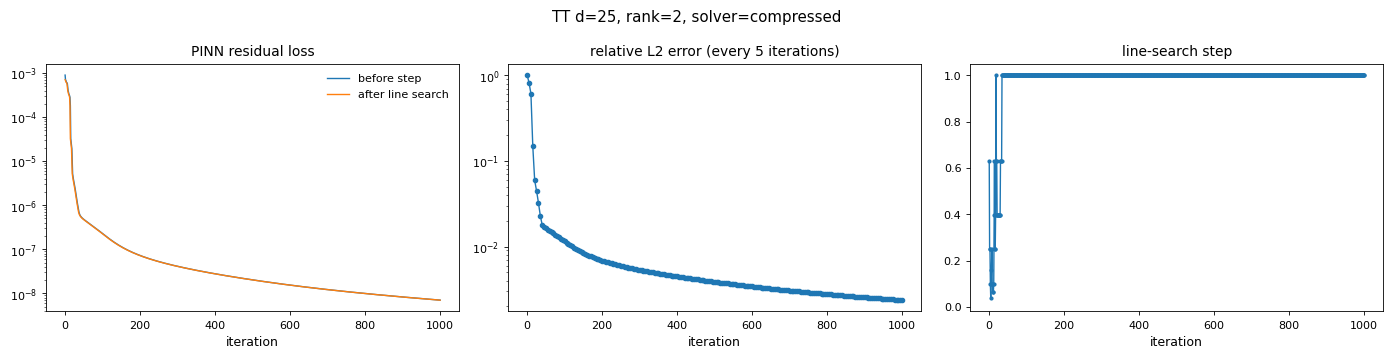

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
fig.suptitle(f"{BASE.format.upper()} d={BASE.d}, rank={model.c}, solver={model.solver_used()}")
iteration_axis = np.arange(1, BASE.iterations + 1)

axes[0].plot(iteration_axis, loss_h, label="before step")
axes[0].plot(iteration_axis, new_loss_h, label="after line search")
axes[0].set_yscale("log")
axes[0].set_title("PINN residual loss")
axes[0].set_xlabel("iteration")
axes[0].legend()

axes[1].plot(err_iter_h, err_h, marker="o", ms=3)
axes[1].set_yscale("log")
axes[1].set_title(f"relative L2 error (every {BASE.error_every} iterations)")
axes[1].set_xlabel("iteration")

axes[2].plot(iteration_axis, step_h, marker="o", ms=2)
axes[2].set_title("line-search step")
axes[2].set_xlabel("iteration")
axes[2].set_ylim(-0.02, 1.05)
plt.tight_layout()
plt.show()


## Solution plots

A one-dimensional cut along $z_1$, and the exact and predicted $(z_1,z_2)$ slices, with all other
coordinates fixed at $0.5$. No high-dimensional grid is formed.

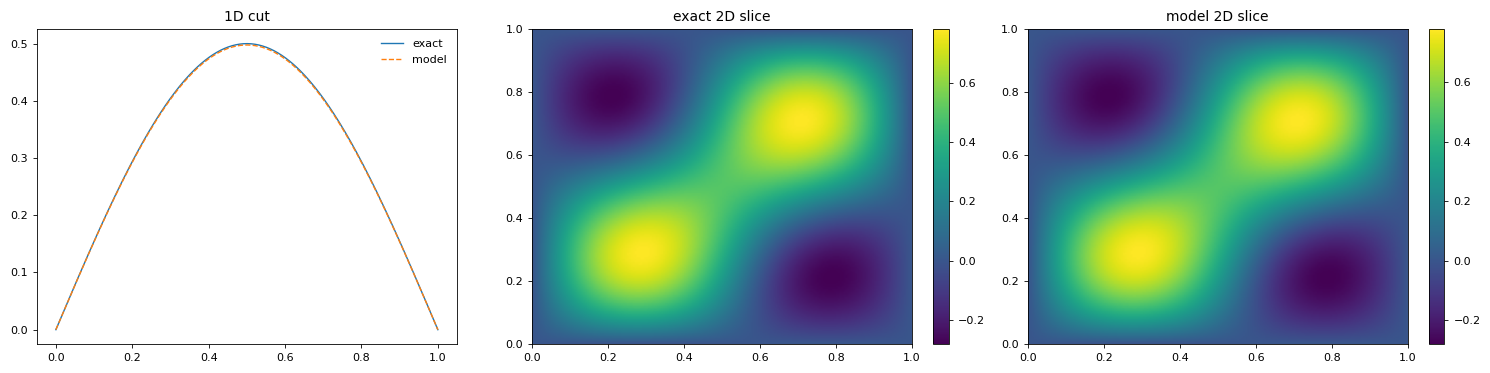

In [12]:

# ------------------------------------------------------------
# One-dimensional cut and two-dimensional slice.  Both are evaluated without
# ever creating a d-dimensional tensor grid.
# ------------------------------------------------------------
N_LINE = 400
N_SLICE = 200
fixed = 0.5 * jnp.ones((BASE.d,))
xs = jnp.linspace(0.0, 1.0, N_SLICE)
ys = jnp.linspace(0.0, 1.0, N_SLICE)
Z1, Z2 = jnp.meshgrid(xs, ys, indexing="ij")

line_X = jnp.tile(fixed[None, :], (N_LINE, 1))
line_X = line_X.at[:, 0].set(jnp.linspace(0.0, 1.0, N_LINE))
line_pred = model.model_points(theta, line_X, scales)
line_exact = model.exact_points(line_X)

pred_slice = model.model_slice(theta, xs, ys, fixed, scales)
exact_slice = model.exact_slice(xs, ys, fixed)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
axes[0].plot(np.asarray(line_X[:, 0]), np.asarray(line_exact), label="exact")
axes[0].plot(np.asarray(line_X[:, 0]), np.asarray(line_pred), "--", label="model")
axes[0].set_title("1D cut")
axes[0].legend()

im1 = axes[1].imshow(np.asarray(exact_slice), origin="lower", extent=(0, 1, 0, 1), aspect="auto")
axes[1].set_title("exact 2D slice")
fig.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(np.asarray(pred_slice), origin="lower", extent=(0, 1, 0, 1), aspect="auto")
axes[2].set_title("model 2D slice")
fig.colorbar(im2, ax=axes[2], fraction=0.046)
plt.tight_layout()
plt.show()


## CP/TT ablation over the target rank $K$

For every $K$ in `ABLATION_K_VALUES`, CP and TT are trained with the fixed architectures and solver
settings from the hyperparameter cell. The first cell only trains and stores the histories; the
next cells plot and export.

In [13]:
# ------------------------------------------------------------
# Run the fixed-architecture CP/TT expressivity ablation.
# This cell trains only; plotting and reporting are in the next cell.
# ------------------------------------------------------------
import gc

if RUN_ABLATION:
    invalid_K = []
    for K in ABLATION_K_VALUES:
        K = int(K)
        is_power_of_two = K >= 1 and (K & (K - 1)) == 0
        fits_dimension = is_power_of_two and 2 * (K.bit_length() - 1) <= D
        if not fits_dimension:
            invalid_K.append(K)
    if invalid_K:
        raise ValueError(
            "Every ablation K must be a positive power of two and satisfy "
            f"2*log2(K) <= D={D}; invalid values: {invalid_K}"
        )

    ablation_results = {"cp": {}, "tt": {}}
    ablation_records = []

    for fmt, solver in (("cp", ABLATION_CP_SOLVER), ("tt", ABLATION_TT_SOLVER)):
        print(f"\n{'=' * 72}\n{fmt.upper()} ablation with fixed branch configuration\n{'=' * 72}")
        for K in ABLATION_K_VALUES:
            cfg = replace(
                BASE,
                format=fmt,
                solver=solver,
                target_rank=int(K),
                iterations=ABLATION_ITERATIONS,
                error_every=ABLATION_ERROR_EVERY,
                seed=ABLATION_SEED,
            )
            ab_model, ab_theta, ab_scales, rec, hist = run(cfg, verbose=True)
            ablation_results[fmt][int(K)] = {"record": rec, "history": hist}
            ablation_records.append(rec)

            # Histories and records have already been moved to NumPy/Python objects.
            del ab_model, ab_theta, ab_scales
            gc.collect()
            if CLEAR_JAX_CACHES_BETWEEN_RUNS:
                jax.clear_caches()

    expected_runs = 2 * len(ABLATION_K_VALUES)
    completed_runs = sum(len(runs) for runs in ablation_results.values())
    if completed_runs != expected_runs:
        raise RuntimeError(
            f"Ablation finished with {completed_runs}/{expected_runs} completed runs."
        )

    print(f"\nAblation completed: {completed_runs} runs.")
    print("Run the next cell to create all plots, the summary table, and exported files.")
else:
    ablation_results = {"cp": {}, "tt": {}}
    ablation_records = []
    print("Ablation skipped because RUN_ABLATION=False.")



CP ablation with fixed branch configuration
[cp/compressed] d=25 rank=4 width=64 K=4 | P_factor=4548, P_total=113700, N_eff=6400 | sampling=fixed | err=7.158e-04 | 65 ms/it (101 error evaluations)
[cp/compressed] d=25 rank=4 width=64 K=8 | P_factor=4548, P_total=113700, N_eff=6400 | sampling=fixed | err=7.106e-01 | 65 ms/it (101 error evaluations)
[cp/compressed] d=25 rank=4 width=64 K=16 | P_factor=4548, P_total=113700, N_eff=6400 | sampling=fixed | err=8.708e-01 | 65 ms/it (101 error evaluations)
[cp/compressed] d=25 rank=4 width=64 K=32 | P_factor=4548, P_total=113700, N_eff=6400 | sampling=fixed | err=1.408e+01 | 65 ms/it (101 error evaluations)

TT ablation with fixed branch configuration
[tt/compressed] d=25 rank=2 width=64 K=4 | P_core=4548, P_total=113440, N_eff=6144 | sampling=fixed | err=2.361e-03 | 61 ms/it (101 error evaluations)
  TT initialization: mode=near_identity, global_scale=0.7187462408546589, mean ||G-I||_RMS=7.189e-02, max=1.431e-01
[tt/compressed] d=25 rank=2 w

### Figures and export

Convergence plots and a one-row-per-run summary table; the figure, CSV table and JSON histories are
exported. No model is retrained.

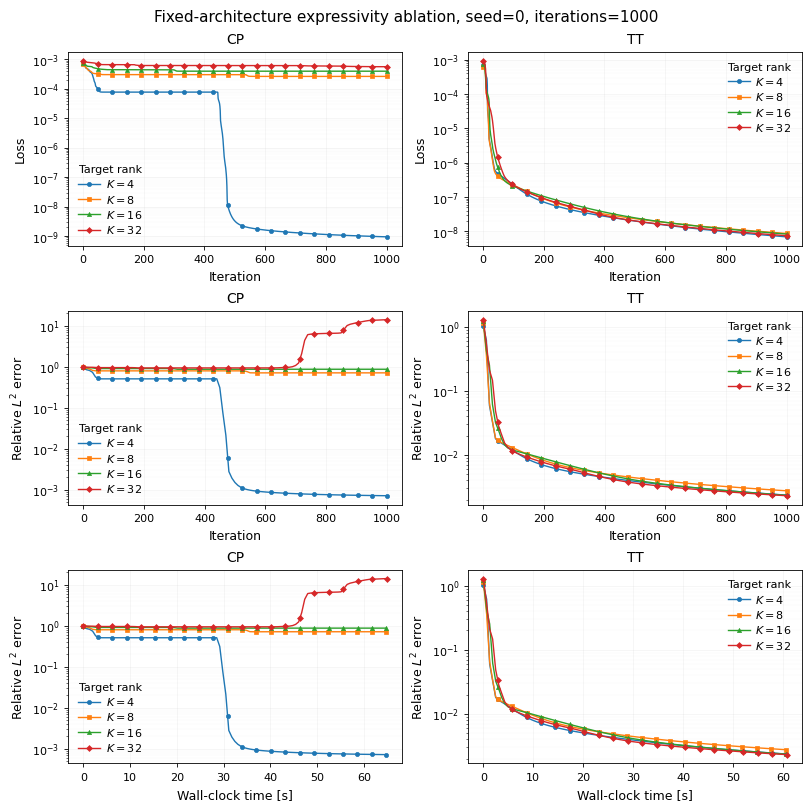

,format,K,solver_used,parameter_block,network_shape,model_rank,width,hidden_layers,parameters_per_factor_or_core,total_parameters,N_eff,tt_init_mode,tt_identity_epsilon,tt_global_scale,iterations,error_every,seed,final_loss,final_rel_L2,best_rel_L2,iteration_time_s,ms_per_iteration
0,CP,4,compressed,factor network,"(1, 64, 64, 4)",4,64,2,4548,113700,6400,near_identity,0.500000,True,1000,10,0,9.3746e-10,7.1575e-04,7.1575e-04,64.803,64.80
1,CP,8,compressed,factor network,"(1, 64, 64, 4)",4,64,2,4548,113700,6400,near_identity,0.500000,True,1000,10,0,2.6298e-04,7.1059e-01,7.0973e-01,64.782,64.78
2,CP,16,compressed,factor network,"(1, 64, 64, 4)",4,64,2,4548,113700,6400,near_identity,0.500000,True,1000,10,0,3.9580e-04,8.7077e-01,8.7077e-01,64.849,64.85
3,CP,32,compressed,factor network,"(1, 64, 64, 4)",4,64,2,4548,113700,6400,near_identity,0.500000,True,1000,10,0,5.6192e-04,1.4075e+01,9.3764e-01,64.871,64.87
4,TT,4,compressed,TT core network,"(1, 64, 64, 4)",2,64,2,4548,113440,6144,near_identity,0.500000,True,1000,10,0,6.9830e-09,2.3612e-03,2.3612e-03,60.664,60.66
5,TT,8,compressed,TT core network,"(1, 64, 64, 4)",2,64,2,4548,113440,6144,near_identity,0.500000,True,1000,10,0,8.7675e-09,2.7575e-03,2.7575e-03,60.533,60.53
6,TT,16,compressed,TT core network,"(1, 64, 64, 4)",2,64,2,4548,113440,6144,near_identity,0.500000,True,1000,10,0,8.4144e-09,2.3493e-03,2.3493e-03,60.669,60.67
7,TT,32,compressed,TT core network,"(1, 64, 64, 4)",2,64,2,4548,113440,6144,near_identity,0.500000,True,1000,10,0,7.5309e-09,2.3103e-03,2.3103e-03,60.709,60.71


saved PNG figure: cp_tt_expressivity_ablation_seed_0.png
saved PDF figure: cp_tt_expressivity_ablation_seed_0.pdf
saved table:      cp_tt_expressivity_ablation_seed_0.csv
saved histories:  cp_tt_expressivity_ablation_seed_0.json


In [14]:
# ------------------------------------------------------------
# Plot, summarize, and export a completed ablation.
# No model training is performed in this cell.
# ------------------------------------------------------------

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def _json_history(history):
    return {
        name: np.asarray(values).tolist()
        for name, values in history.items()
    }


def _uniform_marker_points(x, y, n_markers=22, log_y=True):
    """
    Construct exactly n_markers marker locations, uniformly spaced
    in the plotted x-coordinate.

    The y-values are interpolated from the curve. For logarithmic
    y-axes, interpolation is performed in log(y), so the markers lie
    visually on the plotted semilog curve.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)

    if log_y:
        valid &= (y > 0.0)

    x = x[valid]
    y = y[valid]

    if len(x) == 0:
        return np.array([]), np.array([])

    if len(x) == 1 or x[-1] == x[0]:
        return x.copy(), y.copy()

    # Remove repeated x-values if present.
    x_unique, unique_idx = np.unique(x, return_index=True)
    y_unique = y[unique_idx]

    if len(x_unique) == 1:
        return x_unique, y_unique

    # EXACTLY n_markers equally spaced horizontal locations.
    x_mark = np.linspace(
        x_unique[0],
        x_unique[-1],
        n_markers,
    )

    if log_y:
        y_mark = np.exp(
            np.interp(
                x_mark,
                x_unique,
                np.log(y_unique),
            )
        )
    else:
        y_mark = np.interp(
            x_mark,
            x_unique,
            y_unique,
        )

    return x_mark, y_mark


def _plot_curve_with_uniform_markers(
    ax,
    x,
    y,
    marker,
    label,
    n_markers=22,
):
    """
    Plot a thin curve and then overlay exactly n_markers markers
    uniformly in x.

    The main line carries the marker style in the legend, while
    markevery=[] prevents Matplotlib from placing markers itself.
    """
    x = np.asarray(x)
    y = np.asarray(y)

    # Main curve.
    line, = ax.plot(
        x,
        y,
        marker=marker,
        markevery=[],
        markersize=3.0,
        markeredgewidth=0.5,
        linewidth=1.0,
        label=label,
    )

    # Uniformly spaced marker locations.
    x_mark, y_mark = _uniform_marker_points(
        x,
        y,
        n_markers=n_markers,
        log_y=True,
    )

    # Overlay markers using exactly the same curve color.
    ax.plot(
        x_mark,
        y_mark,
        linestyle="None",
        marker=marker,
        markersize=3.0,
        markeredgewidth=0.5,
        color=line.get_color(),
        markerfacecolor=line.get_color(),
        markeredgecolor=line.get_color(),
        label="_nolegend_",
    )

    return line


# ------------------------------------------------------------
# Check that the ablation has been completed.
# ------------------------------------------------------------

if "ablation_results" not in globals():
    raise RuntimeError(
        "Run the ablation-training cell above before plotting."
    )


missing_runs = {
    fmt: [
        int(K)
        for K in ABLATION_K_VALUES
        if int(K) not in ablation_results.get(fmt, {})
    ]
    for fmt in ("cp", "tt")
}

missing_runs = {
    fmt: values
    for fmt, values in missing_runs.items()
    if values
}

if missing_runs:
    raise RuntimeError(
        "The ablation is incomplete. Run the training cell again before plotting. "
        f"Missing runs: {missing_runs}"
    )


result_dir = Path(ABLATION_RESULT_DIR)
result_dir.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Publication-style plotting defaults.
# ------------------------------------------------------------

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,

    "axes.linewidth": 0.6,

    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.minor.width": 0.4,
    "ytick.minor.width": 0.4,

    "xtick.major.size": 3.0,
    "ytick.major.size": 3.0,
    "xtick.minor.size": 1.8,
    "ytick.minor.size": 1.8,

    "lines.linewidth": 1.0,

    "legend.frameon": False,

    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# ------------------------------------------------------------
# Classical marker sequence.
#
# A given K always has the same marker in every panel.
# ------------------------------------------------------------

marker_cycle = [
    "o",   # circle
    "s",   # square
    "^",   # triangle
    "D",   # diamond
    "v",   # inverted triangle
    "<",   # left triangle
    ">",   # right triangle
    "p",   # pentagon
    "h",   # hexagon
]

marker_for_K = {
    int(K): marker_cycle[i % len(marker_cycle)]
    for i, K in enumerate(ABLATION_K_VALUES)
}


# EXACT number of markers on every curve.
N_MARKERS_PER_CURVE = 22


# ------------------------------------------------------------
# 3 x 2 convergence figure.
#
# Row 1: loss versus iteration.
# Row 2: relative L2 error versus iteration.
# Row 3: relative L2 error versus wall-clock time.
# ------------------------------------------------------------

fig, axes = plt.subplots(
    3,
    2,
    figsize=(8, 8),
    constrained_layout=True,
)

formats = ("cp", "tt")
titles = ("CP", "TT")


for col, (fmt, title) in enumerate(zip(formats, titles)):

    for K in ABLATION_K_VALUES:

        K = int(K)

        hist = ablation_results[fmt][K]["history"]

        iterations = np.arange(
            1,
            len(hist["loss_after"]) + 1,
        )

        loss_after = np.asarray(
            hist["loss_after"]
        )

        error_iterations = np.asarray(
            hist["error_iterations"]
        )

        error_times = np.asarray(
            hist["error_times"]
        )

        relative_l2 = np.asarray(
            hist["relative_l2"]
        )

        marker = marker_for_K[K]
        label = rf"$K={K}$"


        # ----------------------------------------------------
        # Row 1: residual loss versus iteration.
        # EXACTLY 22 uniformly spaced markers.
        # ----------------------------------------------------

        _plot_curve_with_uniform_markers(
            axes[0, col],
            iterations,
            loss_after,
            marker=marker,
            label=label,
            n_markers=N_MARKERS_PER_CURVE,
        )


        # ----------------------------------------------------
        # Row 2: relative L2 error versus iteration.
        # EXACTLY 22 uniformly spaced markers.
        # ----------------------------------------------------

        _plot_curve_with_uniform_markers(
            axes[1, col],
            error_iterations,
            relative_l2,
            marker=marker,
            label=label,
            n_markers=N_MARKERS_PER_CURVE,
        )


        # ----------------------------------------------------
        # Row 3: relative L2 error versus wall-clock time.
        # EXACTLY 22 markers uniformly spaced in TIME.
        # ----------------------------------------------------

        _plot_curve_with_uniform_markers(
            axes[2, col],
            error_times,
            relative_l2,
            marker=marker,
            label=label,
            n_markers=N_MARKERS_PER_CURVE,
        )


    # --------------------------------------------------------
    # Row 1 formatting.
    # --------------------------------------------------------

    axes[0, col].set_title(
        f"{title}"
    )

    axes[0, col].set_xlabel(
        "Iteration"
    )

    axes[0, col].set_ylabel(
        "Loss"
    )

    axes[0, col].set_yscale(
        "log"
    )


    # --------------------------------------------------------
    # Row 2 formatting.
    # --------------------------------------------------------

    axes[1, col].set_title(
        rf"{title}"
    )

    axes[1, col].set_xlabel(
        "Iteration"
    )

    axes[1, col].set_ylabel(
        r"Relative $L^2$ error"
    )

    axes[1, col].set_yscale(
        "log"
    )


    # --------------------------------------------------------
    # Row 3 formatting.
    # --------------------------------------------------------

    axes[2, col].set_title(
        rf"{title}"
    )

    axes[2, col].set_xlabel(
        "Wall-clock time [s]"
    )

    axes[2, col].set_ylabel(
        r"Relative $L^2$ error"
    )

    axes[2, col].set_yscale(
        "log"
    )


    # --------------------------------------------------------
    # Shared publication formatting.
    # --------------------------------------------------------

    for row in range(3):

        ax = axes[row, col]

        ax.grid(
            True,
            which="major",
            linewidth=0.4,
            alpha=0.20,
        )

        ax.grid(
            True,
            which="minor",
            linewidth=0.25,
            alpha=0.10,
        )

        for spine in ax.spines.values():
            spine.set_linewidth(0.6)

        ax.tick_params(
            which="both",
            direction="out",
        )

        ax.legend(
            title="Target rank",
            title_fontsize=8,
            frameon=False,
            handlelength=2.0,
            handletextpad=0.5,
            labelspacing=0.3,
        )


# ------------------------------------------------------------
# Figure title.
# ------------------------------------------------------------

fig.suptitle(
    rf"Fixed-architecture expressivity ablation, "
    rf"seed={ABLATION_SEED}, "
    rf"iterations={ABLATION_ITERATIONS}",
    fontsize=11,
)


# ------------------------------------------------------------
# Save raster and vector versions.
# ------------------------------------------------------------

figure_path = (
    result_dir
    / f"cp_tt_expressivity_ablation_seed_{ABLATION_SEED}.png"
)

figure_pdf_path = (
    result_dir
    / f"cp_tt_expressivity_ablation_seed_{ABLATION_SEED}.pdf"
)


fig.savefig(
    figure_path,
    dpi=400,
    bbox_inches="tight",
)

fig.savefig(
    figure_pdf_path,
    bbox_inches="tight",
)

plt.show()


# ------------------------------------------------------------
# One-row-per-run summary table for the selected seed.
# ------------------------------------------------------------

plot_records = [
    ablation_results[fmt][int(K)]["record"]
    for fmt in formats
    for K in ABLATION_K_VALUES
]


ablation_table = pd.DataFrame(plot_records)

ablation_table["format"] = (
    ablation_table["format"].str.upper()
)

ablation_table["iteration_time_s"] = (
    ablation_table["t_run"]
)

ablation_table["ms_per_iteration"] = (
    1e3 * ablation_table["t_per_iter"]
)


ablation_table = ablation_table.rename(
    columns={
        "target_rank": "K",
        "active_rank": "model_rank",
        "active_width": "width",
        "active_hidden": "hidden_layers",
        "P_axis": "parameters_per_factor_or_core",
        "P": "total_parameters",
        "loss_after_final": "final_loss",
        "err_final": "final_rel_L2",
        "err_best": "best_rel_L2",
    }
)


table_columns = [
    "format",
    "K",
    "solver_used",
    "parameter_block",
    "network_shape",
    "model_rank",
    "width",
    "hidden_layers",
    "parameters_per_factor_or_core",
    "total_parameters",
    "N_eff",
    "tt_init_mode",
    "tt_identity_epsilon",
    "tt_global_scale",
    "iterations",
    "error_every",
    "seed",
    "final_loss",
    "final_rel_L2",
    "best_rel_L2",
    "iteration_time_s",
    "ms_per_iteration",
]


ablation_table = (
    ablation_table[table_columns]
    .sort_values(["format", "K"])
)


display(
    ablation_table.style.format(
        {
            "final_loss": "{:.4e}",
            "final_rel_L2": "{:.4e}",
            "best_rel_L2": "{:.4e}",
            "iteration_time_s": "{:.3f}",
            "ms_per_iteration": "{:.2f}",
        }
    )
)


# ------------------------------------------------------------
# Export summary table.
# ------------------------------------------------------------

csv_path = (
    result_dir
    / f"cp_tt_expressivity_ablation_seed_{ABLATION_SEED}.csv"
)

json_path = (
    result_dir
    / f"cp_tt_expressivity_ablation_seed_{ABLATION_SEED}.json"
)


ablation_table.to_csv(
    csv_path,
    index=False,
)


# ------------------------------------------------------------
# Export complete histories and settings.
# ------------------------------------------------------------

payload = {

    "settings": {

        "K_values": list(
            map(int, ABLATION_K_VALUES)
        ),

        "target_family":
            "paired sine construction: exact CP rank K, maximal TT rank 2",

        "target_requirement":
            "K=2^q and 2q<=d",

        "iterations":
            int(ABLATION_ITERATIONS),

        "error_every":
            int(ABLATION_ERROR_EVERY),

        "seed":
            int(ABLATION_SEED),

        "cp": {
            "rank": int(CP_RANK),
            "width": int(CP_WIDTH),
            "hidden": int(CP_HIDDEN),
            "solver": ABLATION_CP_SOLVER,
        },

        "tt": {
            "rank": int(TT_RANK),
            "width": int(TT_WIDTH),
            "hidden": int(TT_HIDDEN),
            "solver": ABLATION_TT_SOLVER,
            "init_mode": TT_INIT_MODE,
            "identity_epsilon": float(TT_IDENTITY_EPS),
            "global_scale": bool(TT_GLOBAL_SCALE),
        },
    },


    "runs": {

        fmt: {

            str(K): {

                "record":
                    ablation_results[fmt][K]["record"],

                "history":
                    _json_history(
                        ablation_results[fmt][K]["history"]
                    ),
            }

            for K in sorted(
                ablation_results[fmt]
            )
        }

        for fmt in formats
    },
}


with open(json_path, "w") as f:
    json.dump(
        payload,
        f,
        indent=2,
    )


# ------------------------------------------------------------
# Final export summary.
# ------------------------------------------------------------

print(f"saved PNG figure: {figure_path}")
print(f"saved PDF figure: {figure_pdf_path}")
print(f"saved table:      {csv_path}")
print(f"saved histories:  {json_path}")

The last cell draws the $3\times2$ figure used in the manuscript: CP (left) and TT (right); loss
and relative $L^2$ error versus iteration, and relative $L^2$ error versus wall-clock time.

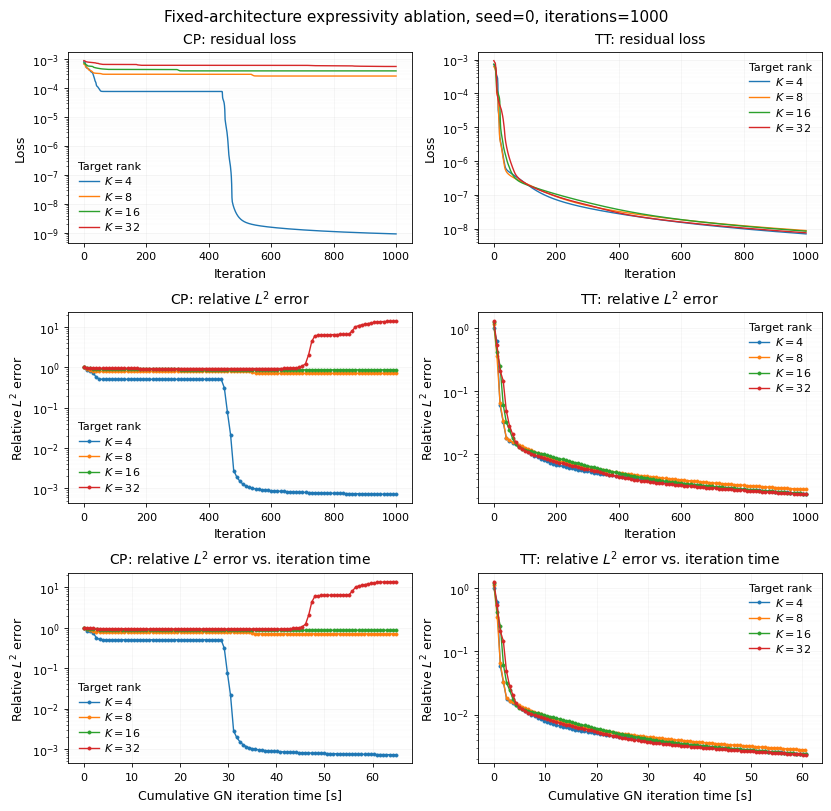

saved PNG figure: cp_tt_expressivity_ablation_seed_0.png
saved PDF figure: cp_tt_expressivity_ablation_seed_0.pdf


In [15]:
# ------------------------------------------------------------
# 3 x 2 convergence figure -- publication style.
#
# Row 1: loss versus iteration.
# Row 2: relative L2 error versus iteration.
# Row 3: relative L2 error versus cumulative iteration time.
# ------------------------------------------------------------

# Publication-style defaults
plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.minor.width": 0.4,
    "ytick.minor.width": 0.4,
    "xtick.major.size": 3.0,
    "ytick.major.size": 3.0,
    "xtick.minor.size": 1.8,
    "ytick.minor.size": 1.8,
    "lines.linewidth": 1.0,
    "lines.markersize": 2.5,
    "legend.frameon": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

fig, axes = plt.subplots(
    3,
    2,
    figsize=(8.2, 8.0),
    constrained_layout=True,
)

formats = ("cp", "tt")
titles = ("CP", "TT")

for col, (fmt, title) in enumerate(zip(formats, titles)):
    for K in ABLATION_K_VALUES:
        hist = ablation_results[fmt][int(K)]["history"]
        iterations = np.arange(1, len(hist["loss_after"]) + 1)
        label = rf"$K={K}$"

        # Loss vs iteration
        axes[0, col].plot(
            iterations,
            hist["loss_after"],
            linewidth=1.0,
            label=label,
        )

        # Relative L2 error vs iteration
        axes[1, col].plot(
            hist["error_iterations"],
            hist["relative_l2"],
            marker="o",
            markersize=2.3,
            markeredgewidth=0.5,
            linewidth=1.0,
            label=label,
        )

        # Relative L2 error vs cumulative time
        axes[2, col].plot(
            hist["error_times"],
            hist["relative_l2"],
            marker="o",
            markersize=2.3,
            markeredgewidth=0.5,
            linewidth=1.0,
            label=label,
        )

    axes[0, col].set_title(f"{title}: residual loss")
    axes[0, col].set_xlabel("Iteration")
    axes[0, col].set_ylabel("Loss")
    axes[0, col].set_yscale("log")

    axes[1, col].set_title(rf"{title}: relative $L^2$ error")
    axes[1, col].set_xlabel("Iteration")
    axes[1, col].set_ylabel(r"Relative $L^2$ error")
    axes[1, col].set_yscale("log")

    axes[2, col].set_title(
        rf"{title}: relative $L^2$ error vs. iteration time"
    )
    axes[2, col].set_xlabel("Cumulative GN iteration time [s]")
    axes[2, col].set_ylabel(r"Relative $L^2$ error")
    axes[2, col].set_yscale("log")

    for row in range(3):
        ax = axes[row, col]

        # Very light publication-style grid
        ax.grid(
            True,
            which="major",
            linewidth=0.4,
            alpha=0.20,
        )
        ax.grid(
            True,
            which="minor",
            linewidth=0.25,
            alpha=0.10,
        )

        # Thin spines
        for spine in ax.spines.values():
            spine.set_linewidth(0.6)

        ax.tick_params(
            which="both",
            direction="out",
        )

        ax.legend(
            title=r"Target rank",
            title_fontsize=8,
            frameon=False,
            handlelength=1.8,
            handletextpad=0.5,
            labelspacing=0.3,
        )

fig.suptitle(
    rf"Fixed-architecture expressivity ablation, "
    rf"seed={ABLATION_SEED}, iterations={ABLATION_ITERATIONS}",
    fontsize=11,
)

# Raster version
figure_path = (
    result_dir
    / f"cp_tt_expressivity_ablation_seed_{ABLATION_SEED}.png"
)
fig.savefig(
    figure_path,
    dpi=400,
    bbox_inches="tight",
)

# Vector version -- preferable for publication
figure_pdf_path = (
    result_dir
    / f"cp_tt_expressivity_ablation_seed_{ABLATION_SEED}.pdf"
)
fig.savefig(
    figure_pdf_path,
    bbox_inches="tight",
)

plt.show()

print(f"saved PNG figure: {figure_path}")
print(f"saved PDF figure: {figure_pdf_path}")